In [1]:
import numpy as np
import params
from basis import *
from matplotlib import pyplot as plt

In [2]:
init = np.array((0,  #A
                 0,  #B
                 0,  #P
                 10 #S
                 ))



In [3]:
#case1 
value = np.array((40., #beta_s
                  1.,   #gamma_s
                  1,  #kAon
                  1,  #kAoff
                  10,  #kApon
                  1.,  #kApoff
                  1.,  #alpha
                  4.,  #alphap
                  10.,  #alpha_s
                  1.,  #alpha_sp
                  1.,  #nu
                  10., #nup
                  1., #kBon
                  1., #kBoff
                  1.  #gammaP
                  ))


In [4]:
case1 = params.case(init,value)

In [5]:
Ts = np.arange(0,15,.01)*2
pf1 = case1.solver(Ts)

s_pf_list = [marginalize(p, case1.states, [0,1]) for p in pf1]
c1_mi_t = [mutual_info(s,p) for (s,p) in s_pf_list] 

In [6]:
value = np.array((40., #beta_s
                  1.,   #gamma_s
                  11.,  #kAon
                  2.,  #kAoff
                  0,  #kApon
                  0.,  #kApoff
                  0.,  #alpha
                  0.,  #alphap
                  0.,  #alpha_s
                  0.,  #alpha_sp
                  11.,  #nu
                  0., #nup
                  1., #kBon
                  1., #kBoff
                  1.  #gammaP
                  ))


In [7]:
case2 = params.case(init,value)
pf2 = case2.solver(Ts)

s_pf_list = [marginalize(p, case2.states, [0,1]) for p in pf2]
c2_mi_t = [mutual_info(s,p) for (s,p) in s_pf_list] 

Text(0.5, 0, 'time')

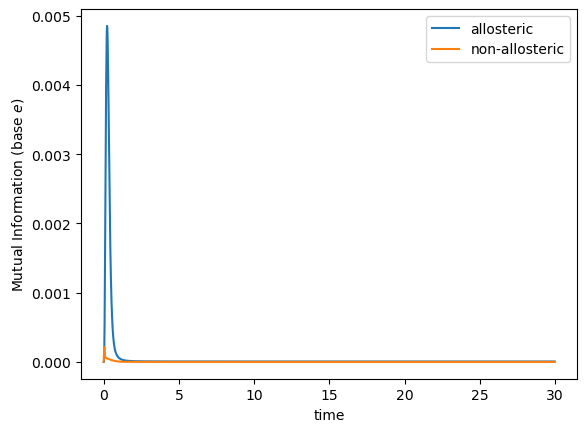

In [8]:
plt.plot(Ts,c1_mi_t,label='allosteric')
plt.plot(Ts,c2_mi_t,label='non-allosteric')
plt.legend()
plt.ylabel('Mutual Information (base $e$)')
plt.xlabel('time')

In [9]:
def expected(prod,prob):
    return np.sum(prod*prob)

Text(0.5, 0, 'time')

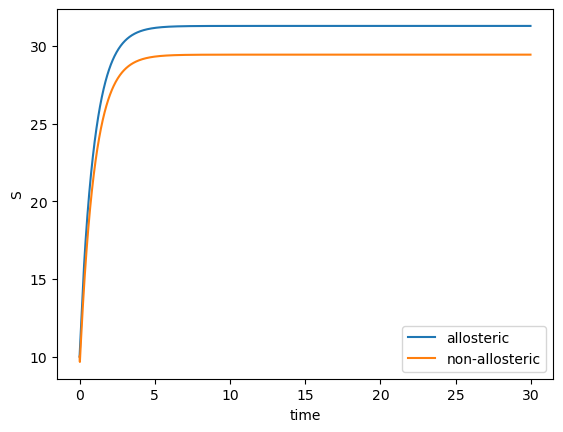

In [10]:
S1 = [marginalize(p, case1.states, 3) for p in pf1]
S2 = [marginalize(p, case2.states, 3) for p in pf2]

S1t = np.array([expected(prod,prob) for (prod,prob) in S1])
S2t = np.array([expected(prod,prob) for (prod,prob) in S2])

plt.plot(Ts,S1t,label='allosteric')
plt.plot(Ts,S2t,label='non-allosteric')
plt.legend()
plt.ylabel('S')
plt.xlabel('time')

Text(0.5, 0, 'time')

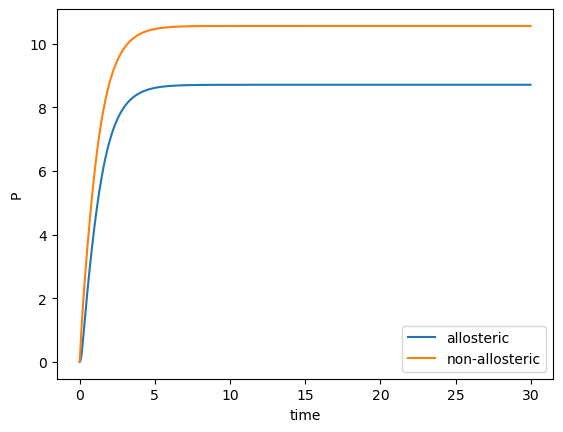

In [11]:
P1 = [marginalize(p, case1.states, 2) for p in pf1]
P2 = [marginalize(p, case2.states, 2) for p in pf2]

P1t = np.array([expected(prod,prob) for (prod,prob) in P1])
P2t = np.array([expected(prod,prob) for (prod,prob) in P2])

plt.plot(Ts,P1t,label='allosteric')
plt.plot(Ts,P2t,label='non-allosteric')
plt.legend()

plt.ylabel('P')
plt.xlabel('time')

In [12]:
s_pf_list

[(array([[0, 0],
         [0, 1],
         [1, 0],
         [1, 1],
         [2, 0],
         [2, 1],
         [3, 0],
         [3, 1]]),
  array([1., 0., 0., 0., 0., 0., 0., 0.])),
 (array([[0, 0],
         [0, 1],
         [1, 0],
         [1, 1],
         [2, 0],
         [2, 1],
         [3, 0],
         [3, 1]]),
  array([1.77732610e-01, 3.77798647e-04, 0.00000000e+00, 0.00000000e+00,
         8.21315391e-01, 5.74199926e-04, 0.00000000e+00, 0.00000000e+00])),
 (array([[0, 0],
         [0, 1],
         [1, 0],
         [1, 1],
         [2, 0],
         [2, 1],
         [3, 0],
         [3, 1]]),
  array([0.10979212, 0.0010873 , 0.        , 0.        , 0.88505613,
         0.00406445, 0.        , 0.        ])),
 (array([[0, 0],
         [0, 1],
         [1, 0],
         [1, 1],
         [2, 0],
         [2, 1],
         [3, 0],
         [3, 1]]),
  array([0.10166492, 0.00195498, 0.        , 0.        , 0.88549233,
         0.01088776, 0.        , 0.        ])),
 (array([[0, 0],
    

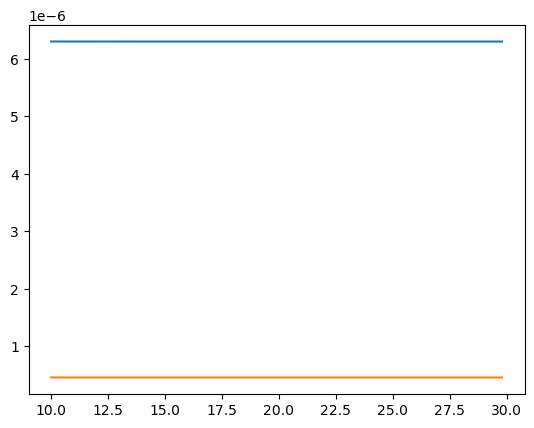

In [13]:
ind = np.arange(500,Ts.size,10,dtype=int)
plt.plot(Ts[ind],np.array(c1_mi_t)[ind],label='allosteric')
plt.plot(Ts[ind],np.array(c2_mi_t)[ind],label='non-allosteric')

In [16]:
c1_mi_t[-1]

6.300653712556542e-06

In [17]:
c2_mi_t[-1]

4.5093888443984326e-07